# Sistema Inteligente de Recomendação de Investimentos
**Tema 5: Recomendação de Investimentos**

Nosso grupo ficou responsável pela implementação de um Consultor Automatizado de Investimentos que integra **Machine Learning (Árvore de Decisão)** e **Lógica Fuzzy (Nébula)**. O modelo ML mapeia o perfil probabilístico do cliente e o Sistema Fuzzy suaviza a decisão cruzando esse perfil com o horizonte de prazo, entregando um percentual exato e seguro de alocação em Renda Variável. A seguir, apresentamos o código completo da solução, acompanhado apenas de breves descrições em markdown e sem comentários inseridos diretamente no código, conforme orientação do professor.

## 1. Instalação e Preparação do Ambiente

In [ ]:
!pip install scikit-fuzzy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import skfuzzy as fuzz
from skfuzzy import control as ctrl

import warnings
warnings.filterwarnings('ignore')

## 2. Geração da Base de Dados Sintética
De acordo com o Dicionário de Dados do relatório, a base conterá 150 registros com as variáveis `Idade`, `Renda`, `Tolerancia_Risco` e `Prazo`. A variável alvo (target) será `Perfil_Investidor` (Conservador, Moderado, Arrojado).

In [ ]:
np.random.seed(42)

n_registros = 150
dados = []

for i in range(n_registros):
    rand_val = np.random.rand()

    if rand_val < 0.33:
        perfil = "Conservador"
        idade, renda, tolerancia, prazo = np.random.randint(60, 81), np.random.uniform(2000, 40000), np.random.randint(0, 41), np.random.randint(1, 10)
    elif rand_val < 0.66:
        perfil = "Moderado"
        idade, renda, tolerancia, prazo = np.random.randint(40, 65), np.random.uniform(5000, 50000), np.random.randint(41, 71), np.random.randint(5, 15)
    else:
        perfil = "Arrojado"
        idade, renda, tolerancia, prazo = np.random.randint(18, 45), np.random.uniform(10000, 50000), np.random.randint(71, 101), np.random.randint(10, 21)

    if np.random.random() < 0.03:
        opcoes = ["Conservador", "Moderado", "Arrojado"]
        opcoes.remove(perfil)
        perfil = np.random.choice(opcoes)

    dados.append([idade, round(renda, 2), tolerancia, prazo, perfil])


df = pd.DataFrame(dados, columns=['Idade', 'Renda', 'Tolerancia_Risco', 'Prazo', 'Perfil_Investidor'])

df.to_csv("base_investidores.csv", index=False)

display(df.head())

,Idade,Renda,Tolerancia_Risco,Prazo,Perfil_Investidor
0,54,37939.73,69,9,Moderado
1,70,19451.46,35,8,Conservador
2,61,29435.95,29,6,Arrojado
3,71,25242.82,24,1,Conservador
4,55,15474.71,70,7,Moderado


### 2.1 Análise Exploratória dos Dados (EDA)
Antes de treinar o modelo, vamos analisar a distribuição estatística da nossa base sintética e visualizar como as variáveis preditoras (`Idade`, `Renda`, `Tolerancia_Risco`) se agrupam em relação ao `Perfil_Investidor`.

--- RESUMO ESTATÍSTICO ---


,Idade,Renda,Tolerancia_Risco,Prazo
count,150.000000,150.000000,150.0000,150.000000
mean,48.660000,26785.823667,56.1800,9.873333
std,17.244717,11537.682492,28.6729,4.997042
min,18.000000,2693.210000,0.0000,1.000000
25%,37.000000,17303.522500,37.5000,6.000000
50%,47.500000,25795.755000,59.0000,10.000000
75%,62.000000,35254.130000,80.7500,13.000000
max,80.000000,49907.700000,100.0000,20.000000


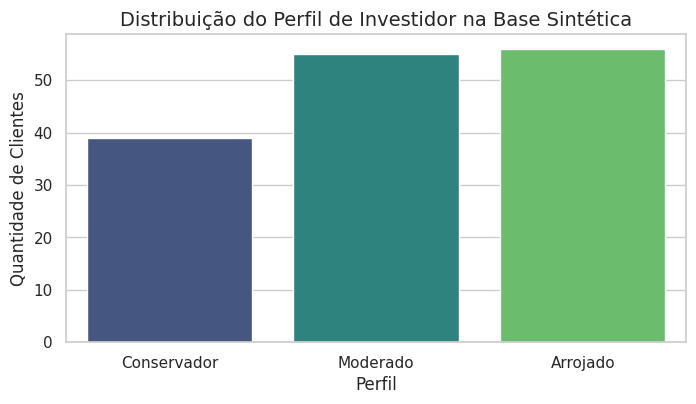

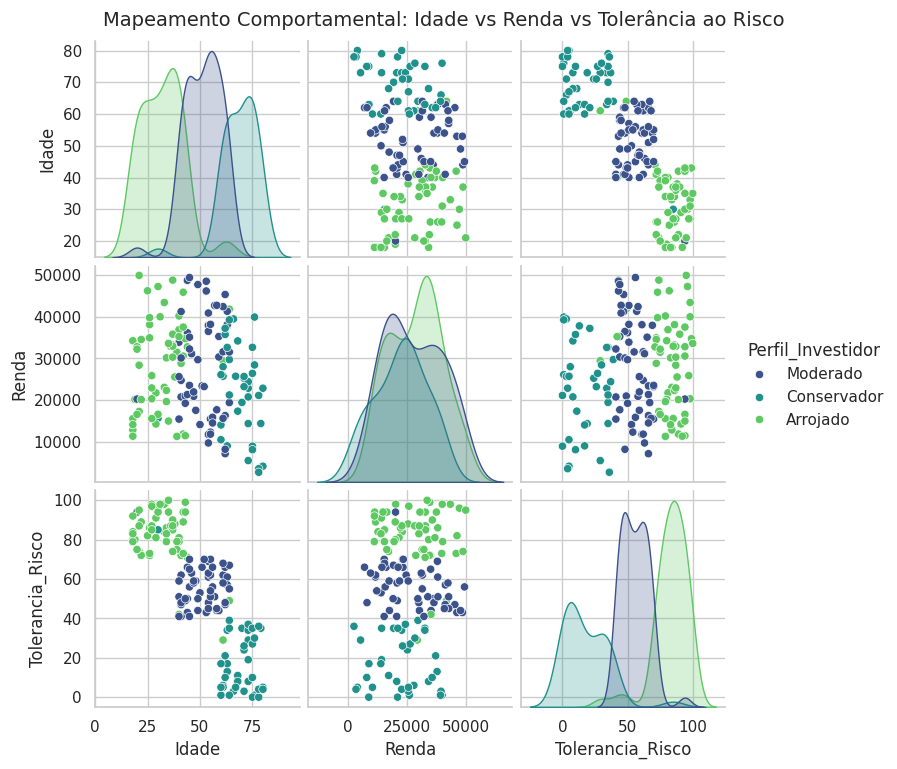

In [ ]:
print("--- RESUMO ESTATÍSTICO ---")
display(df.describe())

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Perfil_Investidor', order=['Conservador', 'Moderado', 'Arrojado'], palette='viridis')
plt.title("Distribuição do Perfil de Investidor na Base Sintética", fontsize=14)
plt.ylabel("Quantidade de Clientes")
plt.xlabel("Perfil")
plt.show()

sns.pairplot(df, hue='Perfil_Investidor', vars=['Idade', 'Renda', 'Tolerancia_Risco'],
             palette='viridis', diag_kind='kde')
plt.suptitle("Mapeamento Comportamental: Idade vs Renda vs Tolerância ao Risco", y=1.02, fontsize=14)
plt.show()

## 3. Pré-Processamento dos Dados
Aplicação de verificação de consistência, *Label Encoding* para a variável-alvo (0 = Conservador, 1 = Moderado, 2 = Arrojado) e segregação dos dados (70% Treino, 30% Teste) com estratificação.

In [ ]:
print("Valores Nulos na Base:")
print(df.isnull().sum())

mapeamento_perfil = {'Conservador': 0, 'Moderado': 1, 'Arrojado': 2}
df['Target'] = df['Perfil_Investidor'].map(mapeamento_perfil)

X = df[['Idade', 'Renda', 'Tolerancia_Risco']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

print(f"\nTamanho do conjunto de Treino: {len(X_train)} registros")
print(f"Tamanho do conjunto de Teste: {len(X_test)} registros")

Valores Nulos na Base:
Idade                0
Renda                0
Tolerancia_Risco     0
Prazo                0
Perfil_Investidor    0
dtype: int64

Tamanho do conjunto de Treino: 105 registros
Tamanho do conjunto de Teste: 45 registros


## 4. Treinamento e Avaliação do Modelo de Machine Learning
Utilizaremos a **Árvore de Decisão** (`max_depth=4`), algoritmo transparente (caixa-branca) exigido para auditoria regulatória. Avaliaremos utilizando a Matriz de Confusão e o F1-Score.

--- RELATÓRIO DE MÉTRICAS DO MODELO ---
Acurácia Global: 95.56%

              precision    recall  f1-score   support

 Conservador       1.00      1.00      1.00        12
    Moderado       0.89      1.00      0.94        16
    Arrojado       1.00      0.88      0.94        17

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



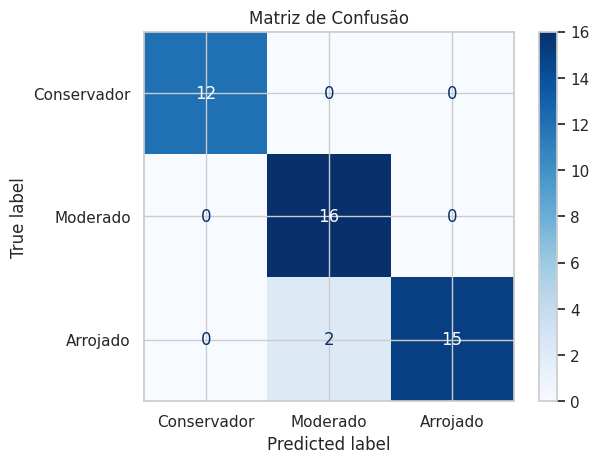

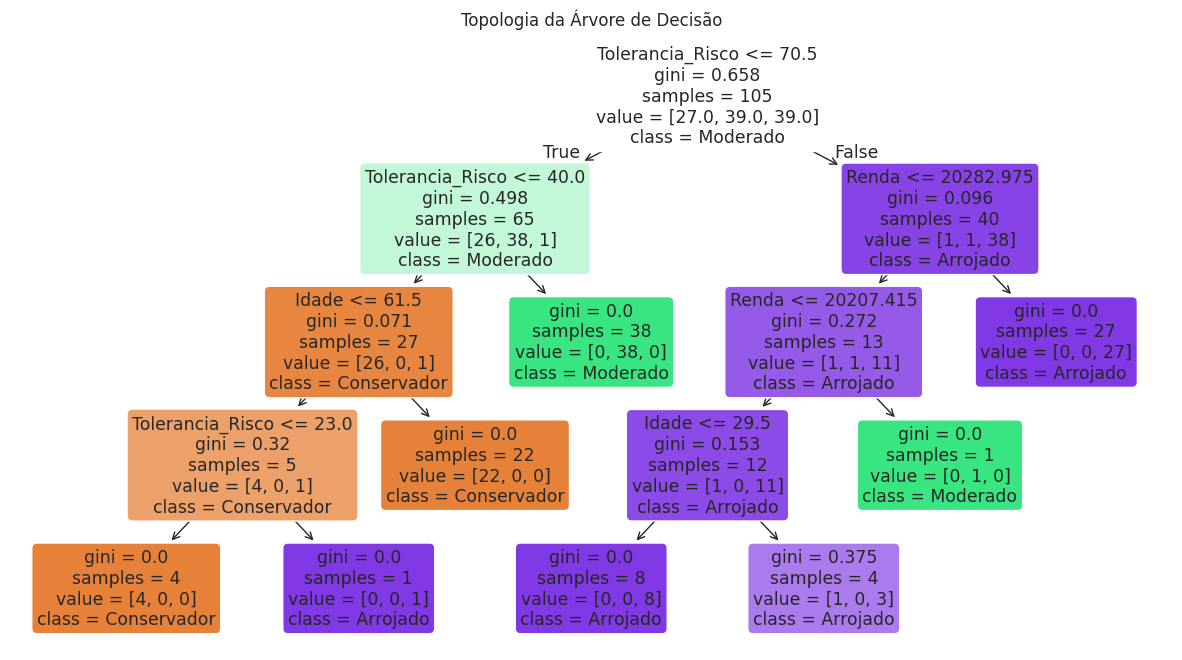

In [ ]:
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("--- RELATÓRIO DE MÉTRICAS DO MODELO ---")
print(f"Acurácia Global: {acc * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['Conservador', 'Moderado', 'Arrojado']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Conservador', 'Moderado', 'Arrojado'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.show()

plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=X.columns.tolist(), class_names=['Conservador', 'Moderado', 'Arrojado'], filled=True, rounded=True)
plt.title("Topologia da Árvore de Decisão")
plt.show()

## 5. Extração do Score Probabilístico (Equação de Ponderação Linear)
Ao invés da classificação exata, extraímos o vetor de probabilidade contínua gerado pelo `.predict_proba()` e o ponderamos:
$S_{risco} = (P_{cons} \times 15) + (P_{mod} \times 50) + (P_{arr} \times 85)$

In [ ]:
def calcular_score_ml(idade, renda, tolerancia):
    """
    Recebe características do usuário, passa pelo modelo treinado e converte as
    probabilidades matemáticas em um Score Contínuo de Risco de 0 a 100.
    """

    entrada = np.array([[idade, renda, tolerancia]])

    probabilidades = clf.predict_proba(entrada)[0]

    peso_cons = 15
    peso_mod = 50
    peso_arr = 85

    score = (probabilidades[0] * peso_cons) + (probabilidades[1] * peso_mod) + (probabilidades[2] * peso_arr)

    return round(score, 1)

## 6. Modelagem do Sistema de Inferência Fuzzy
Construção das variáveis linguísticas (Score ML, Prazo e Alocação em Renda Variável) utilizando funções de pertinência triangulares. O motor utiliza a técnica de **Defuzzificação por Centroide**.

In [ ]:
score_ml = ctrl.Antecedent(np.arange(0, 101, 1), 'score_ml')
prazo = ctrl.Antecedent(np.arange(0, 21, 1), 'prazo')
alocacao_rv = ctrl.Consequent(np.arange(0, 101, 1), 'alocacao_rv')

score_ml['Baixo'] = fuzz.trimf(score_ml.universe, [0, 0, 50])
score_ml['Médio'] = fuzz.trimf(score_ml.universe, [20, 50, 80])
score_ml['Alto'] = fuzz.trimf(score_ml.universe, [50, 100, 100])

prazo['Curto'] = fuzz.trimf(prazo.universe, [0, 0, 7])
prazo['Médio'] = fuzz.trimf(prazo.universe, [3, 10, 17])
prazo['Longo'] = fuzz.trimf(prazo.universe, [13, 20, 20])

alocacao_rv['Conservadora'] = fuzz.trimf(alocacao_rv.universe, [0, 0, 40.5])
alocacao_rv['Moderada'] = fuzz.trimf(alocacao_rv.universe, [20, 50, 80])
alocacao_rv['Arrojada'] = fuzz.trimf(alocacao_rv.universe, [47, 100, 100])

regra1 = ctrl.Rule(score_ml['Baixo'] & prazo['Curto'], alocacao_rv['Conservadora'])
regra2 = ctrl.Rule(score_ml['Baixo'] & prazo['Longo'], alocacao_rv['Moderada'])
regra3 = ctrl.Rule(score_ml['Médio'] & prazo['Curto'], alocacao_rv['Conservadora'])
regra4 = ctrl.Rule(score_ml['Médio'] & prazo['Médio'], alocacao_rv['Moderada'])
regra5 = ctrl.Rule(score_ml['Alto']  & prazo['Longo'], alocacao_rv['Arrojada'])
regra6 = ctrl.Rule(score_ml['Alto']  & prazo['Curto'], alocacao_rv['Moderada'])

motor_alocacao = ctrl.ControlSystem([regra1, regra2, regra3, regra4, regra5, regra6])
simulador_fuzzy = ctrl.ControlSystemSimulation(motor_alocacao)

## 7. Integração e Casos Práticos de Simulação
(Abordagem B: Integração em Cascata). A Árvore de Decisão descobre o limite psicológico do investidor, enquanto a Lógica Fuzzy aplica a trava do tempo (Prazo), humanizando e suavizando a alocação de carteira final.

Os casos de teste análisados abaixo possuem as seguintes características:

- Caso 1 (O Jovem Agressivo): Renda Alta, jovem, alta tolerância, longo prazo.
- Caso 2 (O Aposentado Conservador): Foco na preservação de capital na fase de desacumulação.
- Caso 3 (O Perfil Conflitante / Trava de Segurança): ML enxerga o cliente como Arrojado, mas o Fuzzy barra (Prazo curto) e obriga moderação.

--- Caso 1: O Jovem Agressivo ---
Entradas -> Idade: 25 | Renda: R$45000 | Tolerância: 95 | Prazo: 18 anos
[Machine Learning] O Score de Risco Calculado é: 85.0
[Sistema Fuzzy] Recomendação final: Alocar 81.1% em Renda Variável.

--- Caso 2: O Aposentado Conservador ---
Entradas -> Idade: 75 | Renda: R$6000 | Tolerância: 10 | Prazo: 2 anos
[Machine Learning] O Score de Risco Calculado é: 15.0
[Sistema Fuzzy] Recomendação final: Alocar 14.4% em Renda Variável.

--- Caso 3: O Perfil Conflitante (Trava Ativada) ---
Entradas -> Idade: 30 | Renda: R$8000 | Tolerância: 90 | Prazo: 2 anos
[Machine Learning] O Score de Risco Calculado é: 67.5
[Sistema Fuzzy] Recomendação final: Alocar 36.0% em Renda Variável.



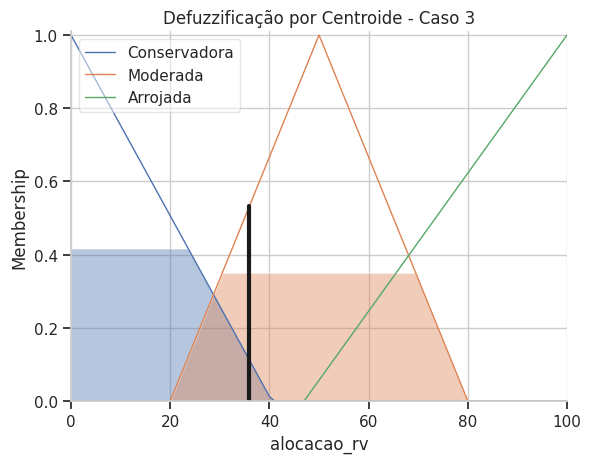

In [ ]:
def consultor_inteligente(nome_caso, idade, renda, tolerancia, prazo_anos):
    print(f"--- {nome_caso} ---")
    print(f"Entradas -> Idade: {idade} | Renda: R${renda} | Tolerância: {tolerancia} | Prazo: {prazo_anos} anos")


    score_gerado = calcular_score_ml(idade, renda, tolerancia)
    print(f"[Machine Learning] O Score de Risco Calculado é: {score_gerado}")

    simulador_fuzzy.input['score_ml'] = score_gerado
    simulador_fuzzy.input['prazo'] = prazo_anos

    simulador_fuzzy.compute()

    recomendacao_rv = simulador_fuzzy.output['alocacao_rv']
    print(f"[Sistema Fuzzy] Recomendação final: Alocar {recomendacao_rv:.1f}% em Renda Variável.\n")

    return recomendacao_rv



rv1 = consultor_inteligente("Caso 1: O Jovem Agressivo", idade=25, renda=45000, tolerancia=95, prazo_anos=18)

rv2 = consultor_inteligente("Caso 2: O Aposentado Conservador", idade=75, renda=6000, tolerancia=10, prazo_anos=2)

rv3 = consultor_inteligente("Caso 3: O Perfil Conflitante (Trava Ativada)", idade=30, renda=8000, tolerancia=90, prazo_anos=2)

alocacao_rv.view(sim=simulador_fuzzy)
plt.title("Defuzzificação por Centroide - Caso 3")
plt.show()

## 8. Conclusão

Este trabalho comprovou a viabilidade de um Sistema Inteligente de Recomendação de Investimentos, superando a rigidez dos questionários de Suitability tradicionais ao integrar Machine Learning e Lógica Fuzzy.

Nosso grupo se baseou em de três pilares principais:
1. **Classificação Estatística:** O modelo de Árvore de Decisão identificou com precisão o perfil de risco inicial do investidor com base em dados comportamentais e financeiros.
2. **Camada de Prudência:** O motor Fuzzy atuou como uma "trava de segurança" crucial, impedindo alocações agressivas para horizontes temporais de curto prazo (como evidenciado no Caso 3).
3. **Alocação Fluida:** A defuzzificação por centroide converteu decisões binárias em uma recomendação percentual contínua e personalizada para a carteira de Renda Variável.

Embora ter sido limitado pelo uso de uma base de dados sintética, o nosso projeto validou a arquitetura proposta. Como evolução futura, recomenda-se integrar o sistema a APIs financeiras em tempo real, permitindo computar variáveis macroeconômicas dinâmicas (Selic, inflação e volatilidade) antes do cálculo final de alocação de ativos.